# Lab 2 — Energy-Tracking Projectile

**Name:** Matthew Nallar  
**Date:** September 6, 2026

In [47]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
def simulate(method, v0=30, theta_deg=50, dt=0.01, g=9.81):
    # Initial conditions: initial velocity, angle,
    
    t = 0.0
    x = 0.0
    y = 0.0
    vx = 0.0
    vy = 0.0
    m = 1.0
        

    theta_rad = np.radians(theta_deg)
    vx, vy = v0 * np.cos(theta_rad), v0 * np.sin(theta_rad)

    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    # Storage lists for plotting
    t_arr, x_arr, y_arr, vx_arr, vy_arr, KE_arr, PE_arr, E_total_arr = [t], [x], [y], [vx], [vy], [KE], [PE], [E_total] 

    # Integration loop
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ax = 0.0
        ay = -g
        if method == "euler":
        # Update velocity (Euler)
            vx_old, vy_old = vx, vy   # save old velocity
            vx = vx + ax * dt
            vy = vy + ay * dt
            x  = x + vx_old * dt      # use OLD velocity for position
            y  = y + vy_old * dt

        elif method == "euler-cromer":
        # ── EULER-CROMER ──
        # Step 1: update velocity first
            vx = vx + ax * dt
            vy = vy + ay * dt

        # Step 2: update position using the NEW velocity
            x = x + vx * dt    # ← this is the only difference from standard Euler
            y = y + vy * dt
            

        t += dt


        
        # Energy tracking
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        # Store
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)
        KE_arr.append(KE)
        PE_arr.append(PE)
        E_total_arr.append(E_total)
    
    return (
        np.array(t_arr),
        np.array(x_arr),
        np.array(y_arr),
        np.array(vx_arr),
        np.array(vy_arr),
        np.array(KE_arr),
        np.array(PE_arr),
        np.array(E_total_arr)
    )

Maximum absolute energy drift: 2.261548 J
Maximum energy drift: 0.502566%
Initial Total Energy: 450.0 J
Final Total Energy: 452.2615483499999 J


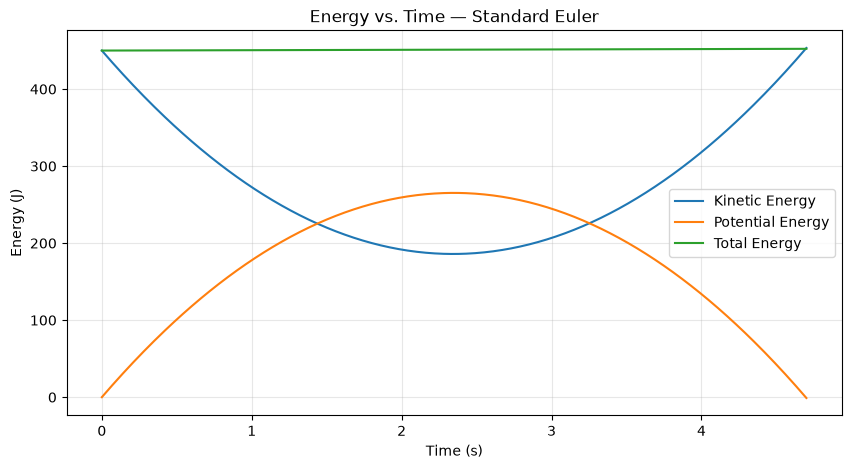

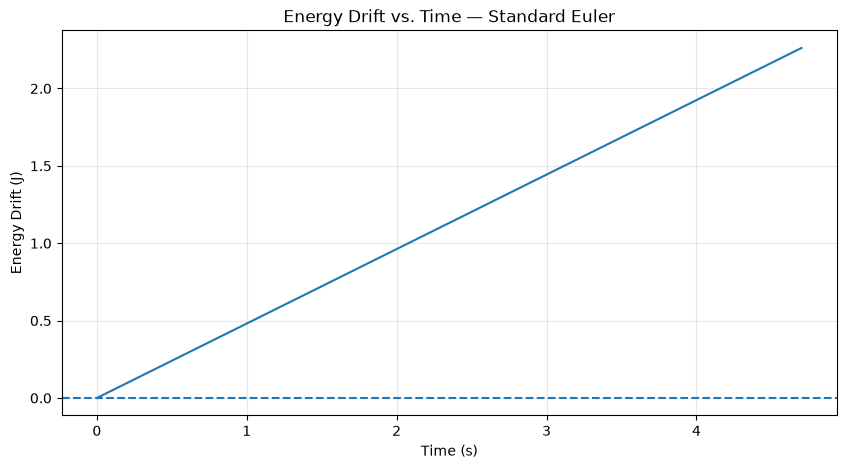

In [94]:
t_e, x_e, y_e, vx_e, vy_e, KE_e, PE_e, E_total_e = simulate(
    method="euler",
    v0=30,
    theta_deg=50,
    dt=0.01,
    g=9.81
)

# Energy drift
energy_drift = E_total_e - E_total_e[0]

# Maximum absolute energy drift
max_drift = np.max(np.abs(energy_drift))

# Percentage of initial energy
percent_drift = (max_drift / E_total_e[0]) * 100

print(f"Maximum absolute energy drift: {max_drift:.6f} J")
print(f"Maximum energy drift: {percent_drift:.6f}%")

print(f"Initial Total Energy:", E_total_e[0], "J")
print(f"Final Total Energy:", E_total_e[-1], "J")

# Plot 1: Energies
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_e, KE_e, label='Kinetic Energy')
ax.plot(t_e, PE_e, label='Potential Energy')
ax.plot(t_e, E_total_e, label='Total Energy')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (J)')
ax.set_title('Energy vs. Time — Standard Euler')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


# Plot 2: Energy drift
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_e, energy_drift)

ax.axhline(0, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy Drift (J)')
ax.set_title('Energy Drift vs. Time — Standard Euler')
ax.grid(True, alpha=0.3)

plt.show()

The drift steady or linear. The projectile is moving the fastest during launch, and when landing, as the potential energy is converted to kinetic energy. The projectile speed being directly related to its kinetic energy. Potnetial energy is greatest when the projectile is at its the highest point. ~0.5% energy is gained by the time the projectile lands.

Maximum absolute energy drift: 2.251925 J
Maximum energy drift: 0.500428%
Initial Total Energy: 450.0 J
Final Total Energy: 447.7480752599999 J


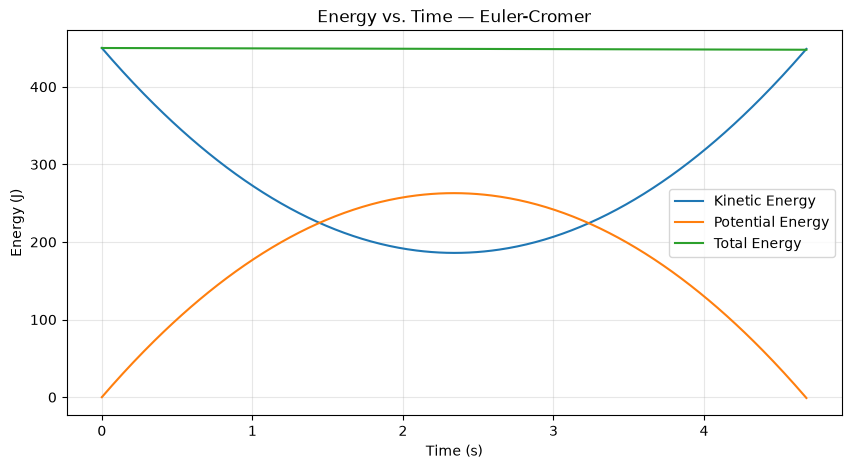

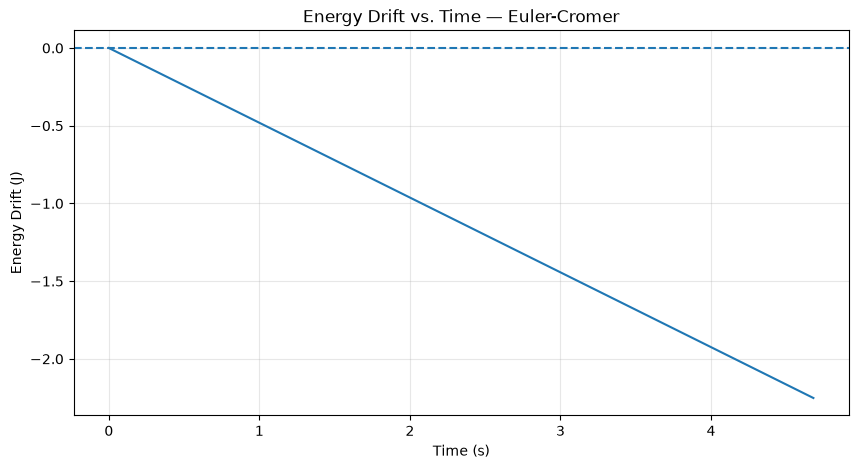

In [96]:
t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_total_ec = simulate(
    method="euler-cromer",
    v0=30,
    theta_deg=50,
    dt=0.01,
    g=9.81
)
# Energy drift
energy_drift = E_total_ec - E_total_ec[0]

# Maximum absolute energy drift
max_drift = np.max(np.abs(energy_drift))

# Percentage of initial energy
percent_drift = (max_drift / E_total_ec[0]) * 100

print(f"Maximum absolute energy drift: {max_drift:.6f} J")
print(f"Maximum energy drift: {percent_drift:.6f}%")

print(f"Initial Total Energy:", E_total_ec[0], "J")
print(f"Final Total Energy:", E_total_ec[-1], "J")

# Plot 1: Energies
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_ec, KE_ec, label='Kinetic Energy')
ax.plot(t_ec, PE_ec, label='Potential Energy')
ax.plot(t_ec, E_total_ec, label='Total Energy')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (J)')
ax.set_title('Energy vs. Time — Euler-Cromer')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


# Plot 2: Energy drift
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_ec, energy_drift)

ax.axhline(0, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy Drift (J)')
ax.set_title('Energy Drift vs. Time — Euler-Cromer')
ax.grid(True, alpha=0.3)

plt.show()

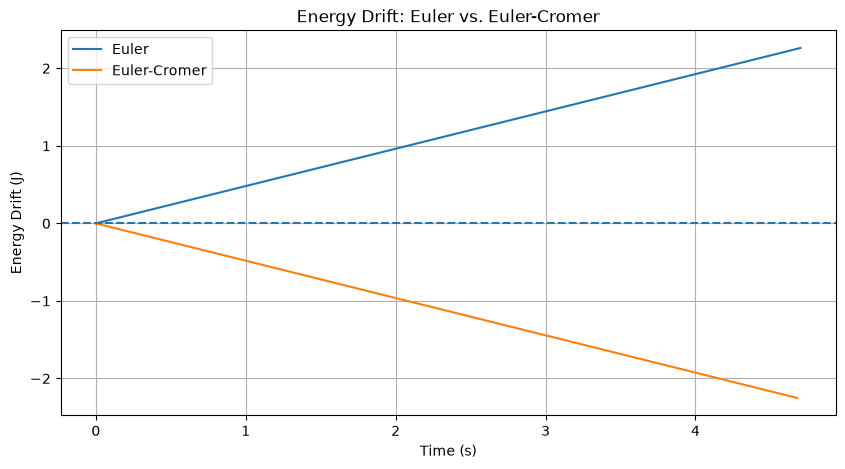

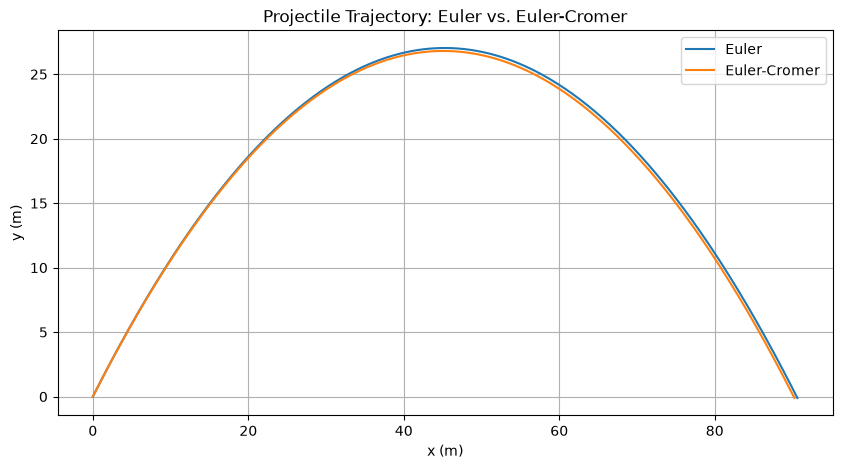

Euler landing range: 90.6331 m
Euler-Cromer landing range: 90.2474 m
Difference in landing range: 0.3857 m


In [75]:
plt.figure(figsize=(10, 5))

plt.plot(t_e, E_e - E_e[0], label="Euler")
plt.plot(t_ec, E_ec - E_ec[0], label="Euler-Cromer")

plt.xlabel("Time (s)")
plt.ylabel("Energy Drift (J)")
plt.title("Energy Drift: Euler vs. Euler-Cromer")
plt.axhline(0, linestyle="--")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(x_e, y_e, label="Euler")
plt.plot(x_ec, y_ec, label="Euler-Cromer")

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Projectile Trajectory: Euler vs. Euler-Cromer")
plt.legend()
plt.grid(True)

plt.show()

range_e = x_e[-1]
range_ec = x_ec[-1]

difference = abs(range_e - range_ec)

print(f"Euler landing range: {range_e:.4f} m")
print(f"Euler-Cromer landing range: {range_ec:.4f} m")
print(f"Difference in landing range: {difference:.4f} m")

Euler uses the old velocity to update position, so its position can overshoot in a way that causes the total energy to increase. Euler-Cromer first updates the velocity and then uses the new velocity to update position, which tends to undershoot the position compared with Euler. These opposite update orders produce opposite energy errors: Euler gains energy while Euler-Cromer loses energy. Thus, even with the same physics and step size, the order of the updates changes how numerical errors accumulate.

Maximum absolute energy drift: 0.045089 J
Maximum energy drift: 0.010020%
dt = 0.10000 | Euler = 23.096664 J | Euler-Cromer = 22.134303 J
dt = 0.05000 | Euler = 11.428037 J | Euler-Cromer = 11.187447 J
dt = 0.02500 | Euler = 5.683945 J | Euler-Cromer = 5.623797 J
dt = 0.01250 | Euler = 2.826935 J | Euler-Cromer = 2.811899 J
dt = 0.00625 | Euler = 1.411588 J | Euler-Cromer = 1.407829 J


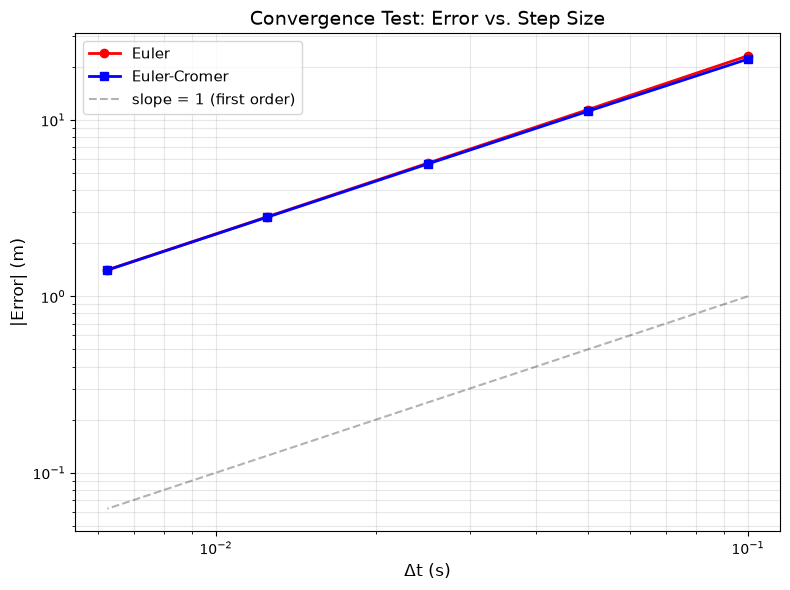

Estimated order p (Euler) = 1.01
Estimated order p (Euler-Cromer) = 0.99


In [98]:
t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_total_ec = simulate(
    method="euler-cromer",
    v0=30,
    theta_deg=50,
    dt=0.0002,
    g=9.81
)
# Energy drift
energy_drift = E_total_ec - E_total_ec[0]

# Maximum absolute energy drift
max_drift = np.max(np.abs(energy_drift))

# Percentage of initial energy
percent_drift = (max_drift / E_total_ec[0]) * 100

print(f"Maximum absolute energy drift: {max_drift:.6f} J")
print(f"Maximum energy drift: {percent_drift:.6f}%")

dt_values = [0.1, 0.05, 0.025, 0.0125, 0.00625]

euler_drift = []
euler_cromer_drift = []

for dt in dt_values:

    # Standard Euler
    results_euler = simulate(
        method="euler",
        v0=30,
        theta_deg=50,
        dt=dt,
        g=9.81
    )

    t_e, x_e, y_e, vx_e, vy_e, KE_e, PE_e, E_e = results_euler

    # Maximum absolute energy drift
    drift_e = E_e - E_e[0]
    max_drift_e = np.max(np.abs(drift_e))
    euler_drift.append(max_drift_e)

    # Euler-Cromer
    results_ec = simulate(
        method="euler-cromer",
        v0=30,
        theta_deg=50,
        dt=dt,
        g=9.81
    )

    t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_ec = results_ec

    # Maximum absolute energy drift
    drift_ec = E_ec - E_ec[0]
    max_drift_ec = np.max(np.abs(drift_ec))
    euler_cromer_drift.append(max_drift_ec)

    print(f"dt = {dt:.5f} | Euler = {max_drift_e:.6f} J | "
          f"Euler-Cromer = {max_drift_ec:.6f} J")

 # Log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(dt_values, euler_drift, 'ro-', label='Euler', linewidth=2)
plt.loglog(dt_values, euler_cromer_drift, 'bs-', label='Euler-Cromer', linewidth=2)
plt.loglog(dt_values, [d**1 * 10 for d in dt_values], 'k--', alpha=0.3, label='slope = 1 (first order)')
plt.xlabel('Δt (s)', fontsize=12)
plt.ylabel('|Error| (m)', fontsize=12)
plt.title('Convergence Test: Error vs. Step Size', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

slope_e = np.polyfit(np.log(dt_values), np.log(euler_drift), 1)[0]
print(f"Estimated order p (Euler) = {slope_e:.2f}")

slope_ec = np.polyfit(np.log(dt_values), np.log(euler_cromer_drift), 1)[0]
print(f"Estimated order p (Euler-Cromer) = {slope_ec:.2f}")

1. The measured order p of standard Euler for energy drift is ~1. It matches what the Week 2 lesson predicted; Euler being a first-order method. Also, the prediction of cutting Δt in half should cut the error roughly in half is also conveyed through the max errors and their respective time step.

2. Euler-Cromer's convergence is very closley similar for smaller time steps, the larger the time steps the more standard Euler diverges. At every step size, the energy drift is smaller.

3. If you need the energy conserved to within 0.01%, a viable option would be using the Euler-Cromer method, roughly at step size dt=0.0002.